In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from parameters import *

In [20]:
# g_arr = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
j = 20
M_arr = [30, 40, 50, 60, 70, 80]

## Ramp Slope Analysis of Dicke model with cavity decay

In [21]:
dataList = []
kappa = kappa_arr[0]
beta = beta_arr[-1]
for g in g_arr:
    dataList1 = []
    for M in M_arr:
        data = np.loadtxt(f"SFF/SFFvsTime,j={j},M={M},g={g},beta={beta},kappa={kappa},ntraj={ntraj}.dat", dtype=complex)
        dataList1.append(data)
    dataList.append(dataList1)

g=0.1, m=-0.07,t=9.0


C:\Users\prasa\AppData\Local\Temp\ipykernel_34772\596494211.py:54: RuntimeWarning: invalid value encountered in power
  plt.plot(data[0], 10**b*data[0]**m,'--')#,label= f"slope = {round(np.real(m),2)}")


g=0.1, m=-0.05,t=9.0
g=0.1, m=0.0,t=9.0
g=0.1, m=-0.04,t=9.0
g=0.1, m=-0.05,t=9.0
g=0.1, m=-0.01,t=9.0
g=0.2, m=0.02,t=9.0
g=0.2, m=-0.23,t=9.0
g=0.2, m=-0.09,t=9.0
g=0.2, m=0.08,t=9.0
g=0.2, m=-0.03,t=9.0
g=0.2, m=-0.11,t=9.0
g=0.3, m=-0.16,t=9.0
g=0.3, m=-0.01,t=9.0
g=0.3, m=0.25,t=9.0
g=0.3, m=0.07,t=9.0
g=0.3, m=-0.1,t=9.0
g=0.3, m=-0.1,t=9.0
g=0.4, m=-0.22,t=9.0
g=0.4, m=-0.35,t=9.0
g=0.4, m=-0.22,t=9.0
g=0.4, m=-0.18,t=9.0
g=0.4, m=-0.26,t=9.0
g=0.4, m=-0.04,t=9.0
g=0.5, m=0.36,t=9.0
g=0.5, m=-0.0,t=9.0
g=0.5, m=0.08,t=9.0
g=0.5, m=0.27,t=9.0
g=0.5, m=0.26,t=9.0
g=0.5, m=0.28,t=9.0
g=0.6, m=1.55,t=5.0
g=0.6, m=1.47,t=5.0
g=0.6, m=1.94,t=5.0
g=0.6, m=1.93,t=5.0
g=0.6, m=0.44,t=5.0
g=0.6, m=2.58,t=5.0
g=0.7, m=7.36,t=5.0
g=0.7, m=7.55,t=5.0
g=0.7, m=6.77,t=5.0
g=0.7, m=6.35,t=5.0
g=0.7, m=6.49,t=5.0
g=0.7, m=6.8,t=5.0
g=0.8, m=7.82,t=3.5
g=0.8, m=8.31,t=3.5
g=0.8, m=7.7,t=3.5
g=0.8, m=7.96,t=3.5
g=0.8, m=7.49,t=3.5
g=0.8, m=7.72,t=3.5
g=0.9, m=9.29,t=2.0
g=0.9, m=11.83,t=3.0
g=0.9,

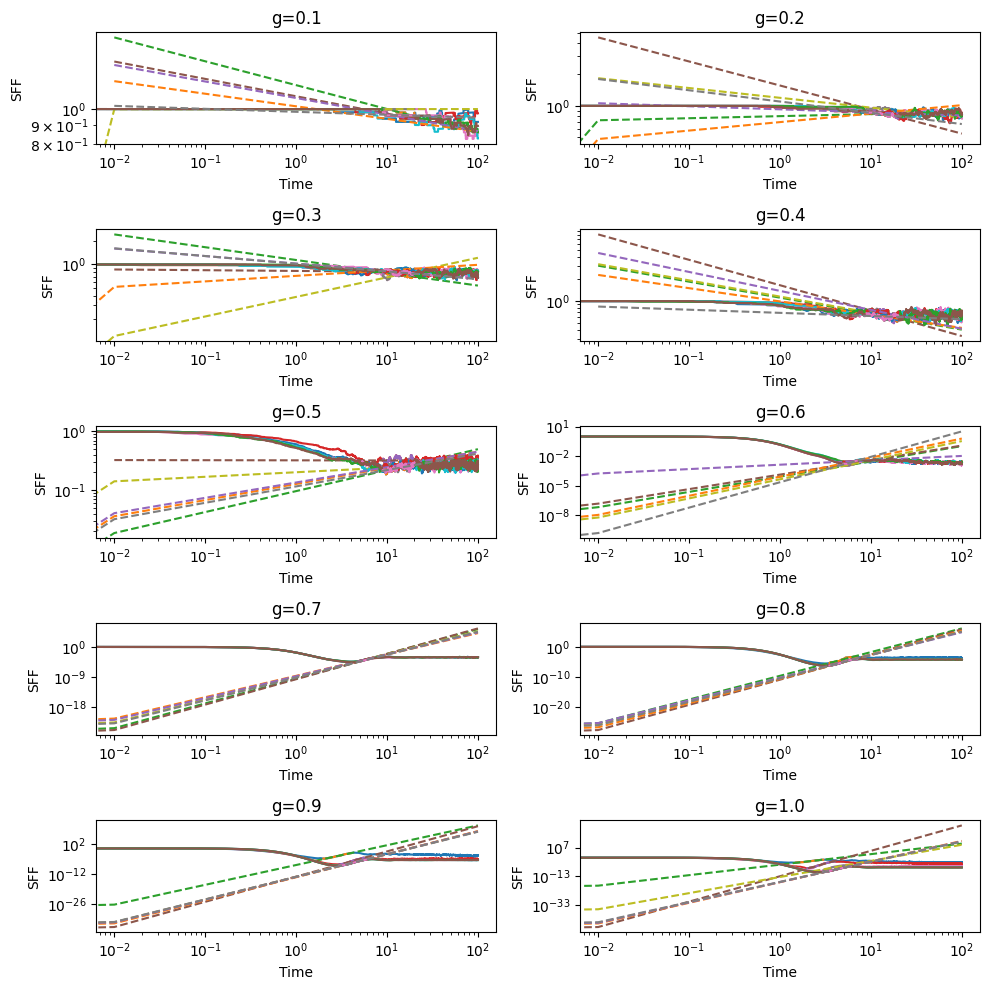

In [22]:
plt.figure(figsize=(10,10))
m_arr_arr = []
for g_ind, dataList1 in enumerate(dataList):
    m_arr = []
    for M_ind, data in enumerate(dataList1):
        #plt.suptitle(f"Dicke Model SFF (j={j}, M={M})")
        plt.subplot(5,2,g_ind+1)
        plt.title(f"g={round(g_arr[g_ind],2)}")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Time")
        plt.ylabel("SFF")
        # plt.xlim(1e-3,1e3)
        # plt.ylim(1e-40,1)
        
        # Isolate the ramp
        indl = int(9e2); indr = int(2e3)

        if g_arr[g_ind] == 0.6:
            indl = int(5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.7:
            indl = int(5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.8:
            indl = int(3.5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.9:
            indl = int(3e2); indr = int(6e2)
        if g_arr[g_ind] == 1.0:
            indl = int(3e2); indr = int(6e2)
        if g_arr[g_ind] == 0.9 and M_arr[M_ind]==30:
            indl = int(2e2); indr = int(4e2)
        if g_arr[g_ind] == 1.0 and M_arr[M_ind]==30:
            indl = int(1.5e2); indr = int(3e2)
        if g_arr[g_ind] == 0.9 and M_arr[M_ind]==40:
            indl = int(3e2); indr = int(6e2)
        if g_arr[g_ind] == 1.0 and M_arr[M_ind]==40:
            indl = int(3e2); indr = int(6e2)
        if g_arr[g_ind] == 1.0 and M_arr[M_ind]==40:
            indl = int(2e2); indr = int(4e2)

        data_ramp = data[indl:indr]

        # Plot the actual data
        data = np.column_stack(data)
        plt.plot(data[0],data[1],label=f"M={M_arr[M_ind]}")

        # Plot the ramp
        data_ramp = np.column_stack(data_ramp)
        plt.plot(data_ramp[0], data_ramp[1])

        # Plot the fit
        # Fit the ramp
        m,b = np.polyfit(np.log10(data_ramp[0]),np.log10(data_ramp[1]),1)
        print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data[0][indl]),2)}")
        plt.plot(data[0], 10**b*data[0]**m,'--')#,label= f"slope = {round(np.real(m),2)}")
        m_arr.append(m)
        plt.tight_layout()
        plt.grid()
    m_arr_arr.append(m_arr)
    # plt.legend()
plt.savefig('plots/Dicke (open) SFF Slope')
plt.show()

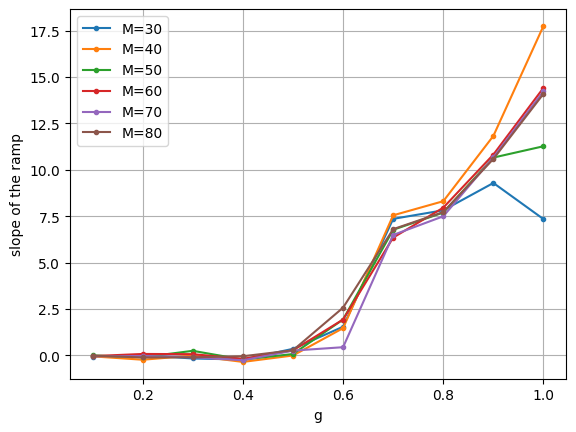

In [27]:
m_arr_arr = np.column_stack(m_arr_arr)
for M_ind, m_arr in enumerate(m_arr_arr):
    # plt.title(f"Dicke Model with Cavity Decay "+r"($\gamma=1$)")
    plt.plot(g_arr,m_arr,'.-',label=f'M={M_arr[M_ind]}')
    plt.xlabel('g')
    plt.ylabel('slope of the ramp')
plt.legend()
plt.grid()
plt.savefig(f"plots/Dicke_model_open_j={j}_slope_ramp_vs_g_for_different_M")
plt.show()